## Analysis of the splits of the dataset

Extract the data from QCArchive

In [2]:
from rdkit import Chem, DataStructs
from rdkit import RDLogger
from rdkit.Chem import AllChem

import deepchem as dc
import numpy as np

from rdkit.DataStructs.cDataStructs import BulkTanimotoSimilarity

RDLogger.DisableLog('rdApp.*')


def smiles_to_fps(smiles, radius=2, nbits=1024):
    mols = [Chem.MolFromSmiles(s) for s in smiles]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits)
           for m in mols if m is not None]
    return fps

def read_smiles_from_csv(file_path, smiles_column='smiles'):
    import pandas as pd
    df = pd.read_csv(file_path)
    smiles = df[smiles_column].tolist()
    return smiles

TEST_SMILES_CSV = 'test_smiles.csv'
TRAIN_SMILES_CSV = 'training_smiles.csv'
VAL_SMILES_CSV = 'validation_smiles.csv'


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/k2584788/.local/share/mamba/envs/charge_model_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/Users/k2584788/.local/share/mamba/envs/charge_model_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [3]:
smiles_in_train = list(set(read_smiles_from_csv(TRAIN_SMILES_CSV)))
smiles_in_test = list(set(read_smiles_from_csv(TEST_SMILES_CSV)))
smiles_in_val = list(set(read_smiles_from_csv(VAL_SMILES_CSV)))

print(f'total length of dataset splits: {len(smiles_in_train)+len(smiles_in_test)+len(smiles_in_val)}')

fps_a = smiles_to_fps(smiles_in_train)
fps_b = smiles_to_fps(smiles_in_test)

arr_a = np.asarray([np.frombuffer(fp.ToBitString().encode('utf-8'), 'S1') == b'1' for fp in fps_a])
arr_b = np.asarray([np.frombuffer(fp.ToBitString().encode('utf-8'), 'S1') == b'1' for fp in fps_b])

max_sim, min_sim = 0, 1
max_pair, min_pair = None, None

same_pairs = []

for i, fp in enumerate(fps_a):
    sims = BulkTanimotoSimilarity(fp, fps_b)
    j_max = np.argmax(sims)
    j_min = np.argmin(sims)
    if sims[j_max] == 1.0:
        same_pairs.append((smiles_in_train[i], smiles_in_test[j_max]))
    if sims[j_max] > max_sim:
        max_sim = sims[j_max]
        max_pair = (smiles_in_train[i], smiles_in_test[j_max])
    if sims[j_min] < min_sim:
        min_sim = sims[j_min]
        min_pair = (smiles_in_train[i], smiles_in_test[j_min])



total length of dataset splits: 58441


In [4]:
len(same_pairs)

1390

In [5]:
len(smiles_in_test)

7510

In [43]:
# Deduplicate test set
smiles_in_test_dedup = [s for s in smiles_in_test if s not in [p[1] for p in same_pairs]]
len(smiles_in_test_dedup)

with open('duplicated_smiles.csv', 'w') as f:
    f.write('train_smiles,test_smiles\n')
    for train_s, test_s in same_pairs:
        f.write(f'{train_s},{test_s}\n')

In [46]:
import numpy as np
import pandas as pd
import math
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.DataStructs.cDataStructs import BulkTanimotoSimilarity
import matplotlib.pyplot as plt
from typing import List, Sequence, Tuple

def smiles_to_fps(smiles: Sequence[str], radius=2, nbits=2048):
    fps, valid_idx = [], []
    for i, s in enumerate(smiles):
        m = Chem.MolFromSmiles(s)
        if m is None:
            continue
        fps.append(AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits))
        valid_idx.append(i)
    return fps, valid_idx

def test_to_train_similarity_analysis_with_filter(
    train_smiles: Sequence[str],
    test_smiles: Sequence[str],
    radius: int = 2,
    nbits: int = 2048,
    batch_size: int = 1024,
    threshold: float = 0.7,
    csv_path: str = "similar_pairs.csv",
    plot: bool = True,
):
    """
    For each test molecule:
      - Find its most similar training molecule
      - Record any with similarity > threshold in a CSV
    """
    fps_train, kept_train = smiles_to_fps(train_smiles, radius, nbits)
    fps_test, kept_test   = smiles_to_fps(test_smiles,  radius, nbits)

    max_sims = np.zeros(len(fps_test), dtype=np.float32)
    best_train_idx = np.zeros(len(fps_test), dtype=int)
    high_pairs = []

    for i, fp_test in enumerate(fps_test):
        sims = np.asarray(BulkTanimotoSimilarity(fp_test, fps_train), dtype=np.float32)
        j_max = int(np.argmax(sims))
        sim_max = float(sims[j_max])
        max_sims[i] = sim_max
        best_train_idx[i] = j_max

        if sim_max > threshold:
            high_pairs.append({
                "similarity": sim_max,
                "test_idx": kept_test[i],
                "train_idx": kept_train[j_max],
                "test_smiles": test_smiles[kept_test[i]],
                "train_smiles": train_smiles[kept_train[j_max]],
            })

    # Compute summary stats
    mean = float(max_sims.mean())
    std = float(max_sims.std())
    s_min = float(max_sims.min())
    s_max = float(max_sims.max())
    stats = {"mean": mean, "std": std, "min": s_min, "max": s_max}

    # Find extremes
    i_most_sim = int(np.argmax(max_sims))
    i_least_sim = int(np.argmin(max_sims))

    most_sim_pair = {
        "similarity": float(max_sims[i_most_sim]),
        "test_idx": kept_test[i_most_sim],
        "train_idx": kept_train[best_train_idx[i_most_sim]],
        "test_smiles": test_smiles[kept_test[i_most_sim]],
        "train_smiles": train_smiles[kept_train[best_train_idx[i_most_sim]]],
    }

    least_sim_pair = {
        "similarity": float(max_sims[i_least_sim]),
        "test_idx": kept_test[i_least_sim],
        "train_idx": kept_train[best_train_idx[i_least_sim]],
        "test_smiles": test_smiles[kept_test[i_least_sim]],
        "train_smiles": train_smiles[kept_train[best_train_idx[i_least_sim]]],
    }

    # Save high-similarity pairs to CSV
    if high_pairs:
        df = pd.DataFrame(high_pairs)
        df.sort_values("similarity", ascending=False, inplace=True)
        df.to_csv(csv_path, index=False)
        print(f"💾 Saved {len(df)} pairs with similarity > {threshold} to '{csv_path}'")
    else:
        print(f"No pairs with similarity > {threshold}")

    if plot:
        plt.figure(figsize=(7,4))
        plt.hist(max_sims, bins=50, edgecolor="black")
        plt.xlabel("Max similarity to training set")
        plt.ylabel("Number of test molecules")
        plt.title("Distribution of nearest-train Tanimoto similarities")
        plt.tight_layout()
        plt.show()

    return max_sims, stats, most_sim_pair, least_sim_pair


💾 Saved 357 pairs with similarity > 0.7 to 'similar_pairs.csv'


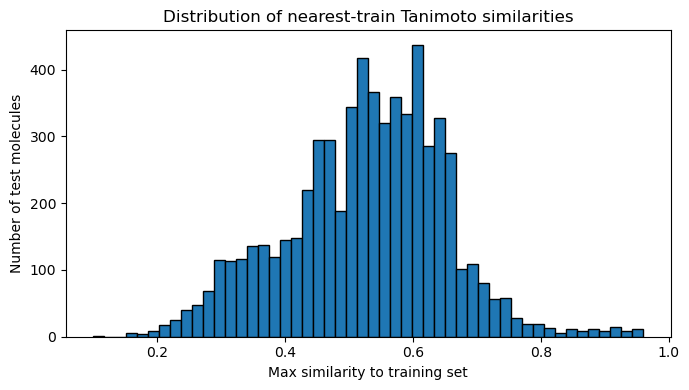

{'mean': 0.5270112752914429, 'std': 0.12524296343326569, 'min': 0.10000000149011612, 'max': 0.9599999785423279}


In [47]:
# training_smiles = [...]
# test_smiles     = [...]
smiles_in_test
fps_train = smiles_to_fps(smiles_in_train, radius=2, nbits=2048)
fps_test  = smiles_to_fps(smiles_in_test_dedup,     radius=2, nbits=2048)
# fps_test_original = smiles_to_fps(smiles_in_test,     radius=2, nbits=2048)
# Exact (streaming) histogram:
hist, stats, most_sim_pair, least_sim_pair = test_to_train_similarity_analysis_with_filter(
    smiles_in_train, smiles_in_test_dedup, batch_size=2048, plot=True
)
# hist, edges, stats = histogram_cross_tanimoto_streaming(
#     fps_train, fps_test_original, bins=60, batch_size=2048
# )
print(stats)


In [ ]:
print(most_sim_pair)

{'similarity': 0.10000000149011612, 'test_idx': 5638, 'train_idx': 27879, 'test_smiles': '[H:2][Si:1]([H:3])([H:4])[H:5]', 'train_smiles': '[H:11][C:3]1([C:4](=[O:5])[C:6]([C:1]([C:2]1([H:9])[H:10])([H:7])[H:8])([H:13])[H:14])[H:12]'}


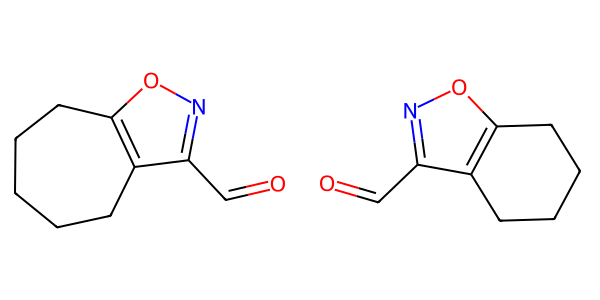

In [41]:
top_pairs_list = []
top_pairs_list.append(Chem.MolFromSmiles(most_sim_pair['test_smiles']))
top_pairs_list.append(Chem.MolFromSmiles(most_sim_pair['train_smiles']))

for mol in top_pairs_list:
    for atom in mol.GetAtoms():
        if atom.HasProp('molAtomMapNumber'):
            atom.ClearProp('molAtomMapNumber')
            
Chem.Draw.MolsToGridImage(top_pairs_list, molsPerRow=2, subImgSize=(300,300))

In [16]:
def plot_hist(hist: np.ndarray, bin_edges: np.ndarray, title: str = "Train vs Test Tanimoto"):
    """Single, clean matplotlib plot."""
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    width = (bin_edges[1] - bin_edges[0])
    plt.figure(figsize=(7,4.2))
    plt.bar(centers, hist, align="center", width=width, edgecolor="black")
    plt.xlabel("Tanimoto similarity")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    plt.show()


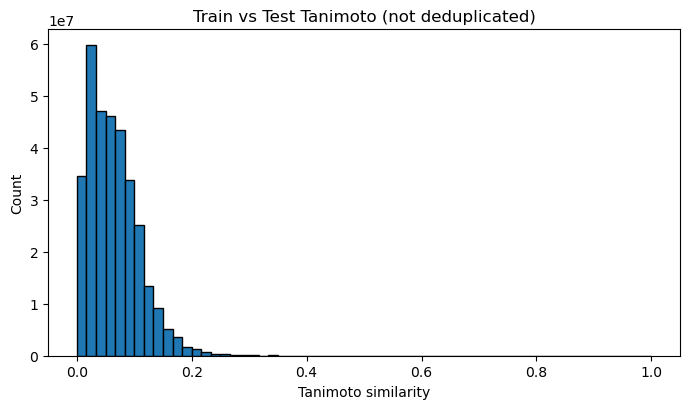

In [17]:
plot_hist(hist, edges, title="Train vs Test Tanimoto (not deduplicated)")

# If |train| * |test| is too big, use sampling:
# hist, edges, stats = sample_cross_pairs_histogram(fps_train, fps_test, n_pairs=2_000_000, bins=60)
# plot_hist(hist, edges, title="Train vs Test Tanimoto (sampled)")


In [8]:
max_pair

('[H:17][C:5]1=[C:6]([S:7][C:3](=[C:4]1[C:11]([H:24])([H:25])[H:26])[C:2]([H:15])([H:16])[C:1]([H:12])([H:13])[H:14])[C:8]([H:18])([C:9]([H:19])([H:20])[H:21])[N:10]([H:22])[H:23]',
 '[H:17][C:5]1=[C:6]([S:7][C:3](=[C:4]1[C:11]([H:24])([H:25])[H:26])[C:2]([H:15])([H:16])[C:1]([H:12])([H:13])[H:14])[C:8]([H:18])([C:9]([H:19])([H:20])[H:21])[N:10]([H:22])[H:23]')

In [7]:
print(len(smiles_in_train))
print(len(smiles_in_test_dedup))

43422
6277


In [10]:
import polars as pl
import pandas as pd

In [11]:
pldf = pl.scan_parquet('./nagl-mbis/scripts/dataset/training.parquet')
df = pldf.collect()
df

smiles,conformation,dipole,charges,mbis-dipoles,mbis-quadrupoles,inv_distance,esp
str,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
"""[H:1][C:2]1=[N:3][O:4][C:5](=[…","[-8.021361, -12.075051, … -5.173953]","[-0.262531, -0.05344, 0.653706]","[0.1289, 0.311379, … -0.585725]","[-0.012833, -0.060851, … -0.055682]","[-0.484481, -0.007447, … -4.813879]","[0.109055, 0.122537, … 0.041624]","[-0.018448, -0.022133, … -0.00097]"
"""[H:1][C:2]1=[N:3][C:4](=[N:17]…","[-16.969399, -14.971485, … 11.1367]","[-1.585516, -0.035823, 0.998643]","[0.126172, 0.240156, … 0.367839]","[-0.074275, 0.0191, … 0.012732]","[-0.481119, -0.001964, … -0.297977]","[0.224876, 0.122549, … 0.025838]","[0.02854, 0.02864, … -0.000256]"
"""[H:1][C:2]1=[N:19][N:17]([C:4]…","[-17.136575, -16.415056, … 15.426192]","[0.889802, -0.394813, … 0.078038]","[0.11094, 0.308872, … -0.389111]","[-0.076061, 0.003973, … -0.088285]","[-0.494182, 0.002224, … -4.629363]","[0.224768, 0.126744, … 0.028341]","[0.013144, 0.014036, … 0.00303]"
"""[H:1][c:2]1[c:10]2[c:9]([c:7](…","[8.400931, -7.19606, … -2.174856]","[-0.047592, -1.456737, -0.108709]","[0.164805, -0.196123, … 0.124524]","[0.034764, 0.00536, … -0.027791]","[-0.460109, 0.001342, … -0.506585]","[0.046207, 0.053254, … 0.03585]","[0.013081, 0.013498, … -0.011246]"
"""[H:1][c:2]1[c:10]2[c:9]([c:7](…","[-5.801655, 9.081896, … 6.741991]","[-1.504812, -0.985321, 0.507241]","[0.168948, -0.164848, … 0.366219]","[0.004387, 0.046524, … -0.015046]","[-0.441425, 0.005547, … -0.293607]","[0.044057, 0.047778, … 0.032794]","[0.024243, 0.024024, … -0.001098]"
…,…,…,…,…,…,…,…
"""[H:12][c:1]1[c:2]2[c:3]([c:4](…","[-5.911556, -2.468599, … -8.978321]","[-0.003638, -0.484402, 0.836595]","[-0.015788, 0.159497, … 0.119893]","[-0.01018, -0.041485, … -0.012429]","[-4.312036, -0.09154, … -0.486979]","[0.127036, 0.083558, … 0.045546]","[0.092856, 0.093376, … 0.065654]"
"""[H:10][C:1]1=[N:5][N:4]([C:3](…","[0.432312, -10.049362, … 1.261232]","[0.054247, 0.886384, 0.842988]","[0.06146, -0.17504, … 0.152854]","[0.017602, -0.015791, … 0.039676]","[-4.077652, 0.034629, … -0.469362]","[0.062475, 0.082812, … 0.04594]","[0.007729, 0.010549, … -0.019509]"
"""[H:1][c:2]1[c:10]2[c:9]([c:7](…","[13.980883, -3.605185, … 17.655257]","[-1.115755, -0.081728, 1.049878]","[0.191247, -0.20844, … 0.396562]","[0.053548, -0.006599, … 0.018725]","[-0.427574, -0.000998, … -0.260075]","[0.042177, 0.048943, … 0.045512]","[-0.005077, -0.007393, … 0.013497]"


In [23]:
import deepchem as dc
import numpy as np
# creation of demo data set with some smiles strings
smiles= ['C', 'CC', 'CCC', 'CCCC', 'CCCCC','C','CC']
set_smiles = list(set(smiles))
Xs = np.zeros(len(set_smiles))
# creation of a deepchem dataset with the smile codes in the ids field
dataset = dc.data.DiskDataset.from_numpy(X=Xs,ids=set_smiles)
maxminsplitter = dc.splits.MaxMinSplitter()
train_dataset, test_dataset = maxminsplitter.train_test_split(dataset)

In [24]:
train_dataset.ids

array(['CCCC', 'C', 'CC', 'CCCCC'], dtype=object)

In [25]:
test_dataset.ids

array(['CCC'], dtype=object)

In [26]:
set_smiles

['CCCC', 'C', 'CC', 'CCC', 'CCCCC']